# DL076 贝叶斯深度学习与模型集合

对应原catalog T4。重启内核并按顺序运行；实验离线，全部数据本地生成。正文解释见lecture.md，练习见lab.md。

In [1]:
# 引入共享的完整实验实现；无网络调用。
from experiment import run
# 另存结果，保留发行版outputs证据。
results = run('notebook_outputs')
# 显示真实训练和评价的结果。
results

{'single': {'in_domain': {'rmse': 0.18356737535321074,
   'gaussian_nll': -0.2758447514603008,
   'coverage_95': 0.945273631840796,
   'mean_width_95': 0.7056000000000002},
  'out_of_domain': {'rmse': 2.4743012508140616,
   'gaussian_nll': 93.68202096591565,
   'coverage_95': 0.2325,
   'mean_width_95': 0.7056000000000001},
  'far_out': {'rmse': 3.3653753021367,
   'gaussian_nll': 173.98424696054,
   'coverage_95': 0.0,
   'mean_width_95': 0.7056000000000002}},
 'ensemble': {'in_domain': {'rmse': 0.18317554095322575,
   'gaussian_nll': -0.2780283680169526,
   'coverage_95': 0.9502487562189055,
   'mean_width_95': 0.7057762751869884},
  'out_of_domain': {'rmse': 2.3931242239930888,
   'gaussian_nll': 46.771352793341684,
   'coverage_95': 0.245,
   'mean_width_95': 0.8616060518323068},
  'far_out': {'rmse': 3.2581342968990192,
   'gaussian_nll': 84.33336682050152,
   'coverage_95': 0.0,
   'mean_width_95': 0.9778668447095977}},
 'last_layer_bayes': {'in_domain': {'rmse': 0.18402681238965

## 数字数组与复核
NPZ保存普通数值数组；关闭pickle并列出形状，确认样本与字段含义。

In [2]:
# 读取本次Notebook真正产生的数据。
import numpy as np
data = np.load('notebook_outputs/data.npz', allow_pickle=False)
# 显示每个字段的形状，结合data_dictionary.md阅读。
{key: data[key].shape for key in data.files}

{'train_x': (100,),
 'train_y': (100,),
 'grid_x': (601,),
 'test_y': (601,),
 'truth': (601,)}

## 自动数学核查
运行数值梯度、结构机制或后验检查；失败会明确中止。

In [3]:
# unittest断言在普通和优化解释器下都生效。
import unittest
import test_experiment
suite = unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
checked = unittest.TextTestRunner(verbosity=2).run(suite)
if not checked.wasSuccessful():
    raise RuntimeError('Numerical checks failed')

test_analytic_parameter_gradient (test_experiment.NumericalTests.test_analytic_parameter_gradient) ... 

ok


test_fit_learns (test_experiment.NumericalTests.test_fit_learns) ... 

ok


test_generator_repeatable_and_shape (test_experiment.NumericalTests.test_generator_repeatable_and_shape) ... 

...

test_predictive_variance_formula (test_experiment.NumericalTests.test_predictive_variance_formula) ... 

ok


test_score_and_input_guards (test_experiment.NumericalTests.test_score_and_input_guards) ... 

ok


----------------------------------------------------------------------
Ran 7 tests in 0.063s

OK


## 内嵌实验结果图
以下图直接使用本Notebook新产生的数组，并未复制旧的显示输出。

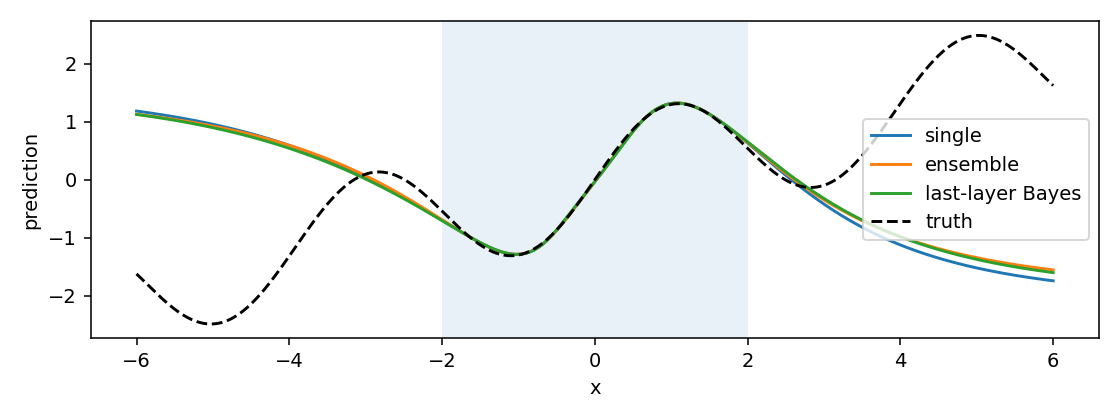

In [4]:
# 本地绘图并显示，无在线图片。
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
from io import BytesIO
pred = np.load('notebook_outputs/predictions.npz', allow_pickle=False)
fig, ax = plt.subplots(figsize=(8, 3))
for k, label in enumerate(['single','ensemble','last-layer Bayes']):
    ax.plot(data['grid_x'], pred['means'][k], label=label)
ax.plot(data['grid_x'], data['truth'], '--', color='black', label='truth')
ax.axvspan(-2,2,alpha=.1)
ax.set(xlabel='x',ylabel='prediction')
ax.legend()
fig.tight_layout()
# 将真实新图编码为PNG，让Notebook离线打开也可见。
buf = BytesIO()
fig.savefig(buf, format='png', dpi=140)
display(Image(data=buf.getvalue()))
plt.close(fig)

## 自我检查
把本次数字与answers.md比较。预测准确、数学实现正确和因果/域外主张是不同问题；请分别写出证据和限制。